   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 42.5 MB/s eta 0:00:00
⚠️ GPU not available. Using CPU (this will be slow).


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

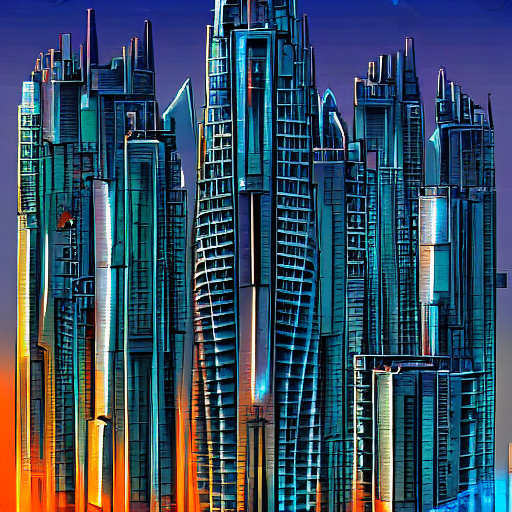

✅ Image generated successfully!


In [8]:
# ==========================================
# Install required libraries
# ==========================================
!pip -q install -U diffusers transformers accelerate safetensors sentencepiece

# ==========================================
# Import libraries
# ==========================================
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

# ==========================================
# Check device
# ==========================================
if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
    print("✅ Using GPU:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    dtype = torch.float32
    print("⚠️ GPU not available. Using CPU (this will be slow).")

# ==========================================
# Load Stable Diffusion model
# ==========================================
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=dtype
)

pipe = pipe.to(device)

# Reduce memory usage
pipe.enable_attention_slicing()

# ==========================================
# Prompt
# ==========================================
prompt = "A futuristic city skyline at sunset, digital art, highly detailed"

# ==========================================
# Generate image
# ==========================================
image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

# ==========================================
# Save image
# ==========================================
image.save("generated_city.png")

# Display image
display(image)

print("✅ Image generated successfully!")